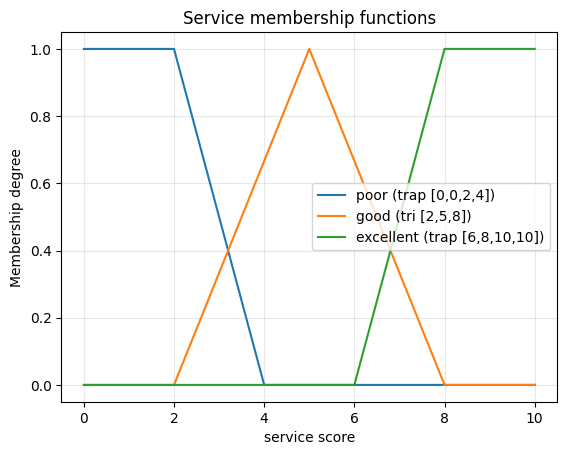

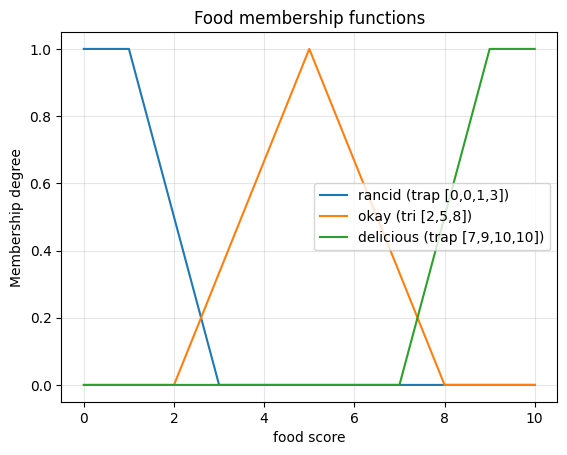

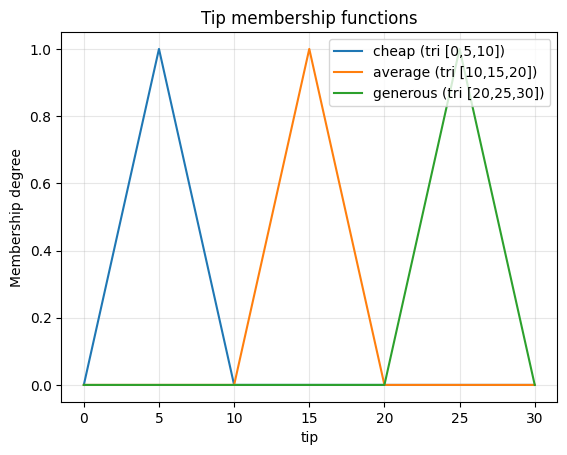

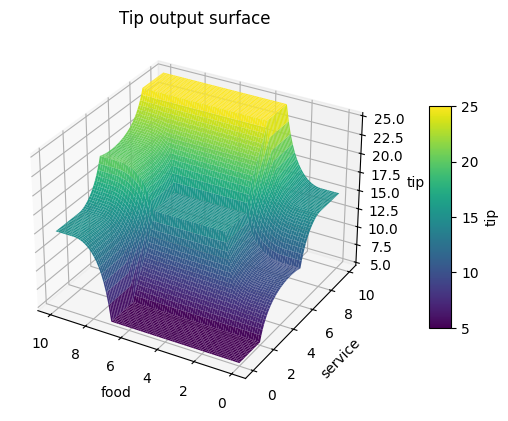

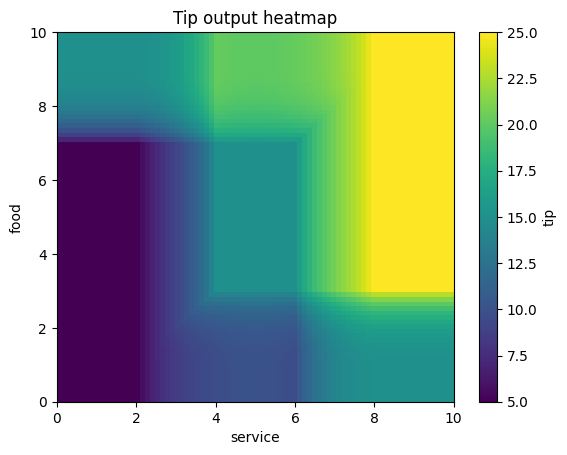

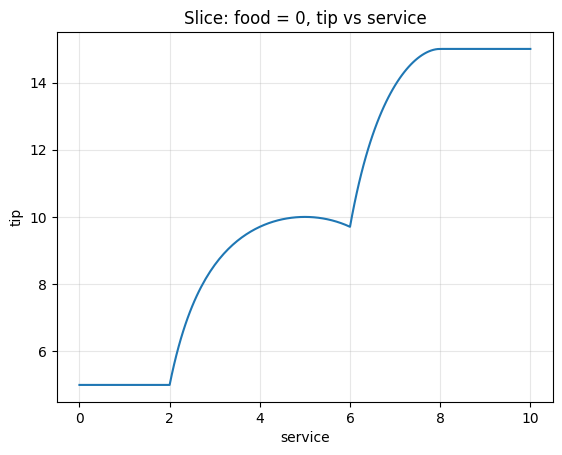

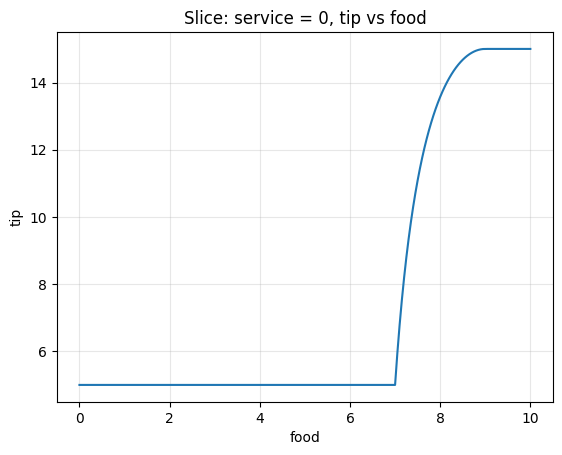

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Membership functions
# -----------------------------
def trimf(x, a, b, c):
    """Triangular membership function with points (a,0), (b,1), (c,0)."""
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)

    # Rising edge
    if b != a:
        idx = (a < x) & (x < b)
        y[idx] = (x[idx] - a) / (b - a)

    # Peak
    y[x == b] = 1.0

    # Falling edge
    if c != b:
        idx = (b < x) & (x < c)
        y[idx] = (c - x[idx]) / (c - b)

    return np.clip(y, 0.0, 1.0)

def trapmf(x, a, b, c, d):
    """Trapezoidal membership function with points (a,0),(b,1),(c,1),(d,0)."""
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)

    # Rising edge
    if b != a:
        idx = (a < x) & (x < b)
        y[idx] = (x[idx] - a) / (b - a)

    # Plateau
    idx = (b <= x) & (x <= c)
    y[idx] = 1.0

    # Falling edge
    if d != c:
        idx = (c < x) & (x < d)
        y[idx] = (d - x[idx]) / (d - c)

    return np.clip(y, 0.0, 1.0)

# -----------------------------
# Universes
# -----------------------------
xs = np.linspace(0, 10, 1001)   # service
xf = np.linspace(0, 10, 1001)   # food
xt = np.linspace(0, 30, 1501)   # tip

# -----------------------------
# Proposed membership functions
# -----------------------------
# Food (from MathWorks tipper example)
food_rancid = trapmf(xf, 0, 0, 1, 3)          # [0,0,1,3]
food_okay = trimf(xf, 2, 5, 8)                # [2,5,8]
food_delicious = trapmf(xf, 7, 9, 10, 10)     # [7,9,10,10]

# Service (simplified: trapezoids/triangles only)
serv_poor = trapmf(xs, 0, 0, 2, 4)            # [0,0,2,4]
serv_good = trimf(xs, 2, 5, 8)                # [2,5,8]
serv_excellent = trapmf(xs, 6, 8, 10, 10)     # [6,8,10,10]

# Tip (from MathWorks tipper example)
tip_cheap = trimf(xt, 0, 5, 10)               # [0,5,10]
tip_average = trimf(xt, 10, 15, 20)           # [10,15,20]
tip_generous = trimf(xt, 20, 25, 30)          # [20,25,30]

# -----------------------------
# Plot helpers
# -----------------------------
def plot_mfs(x, mfs, labels, title, xlabel):
    plt.figure()
    for y, lab in zip(mfs, labels):
        plt.plot(x, y, label=lab)
    plt.ylim(-0.05, 1.05)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Membership degree")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 1) Plot input/output membership functions
plot_mfs(
    xs,
    [serv_poor, serv_good, serv_excellent],
    ["poor (trap [0,0,2,4])", "good (tri [2,5,8])", "excellent (trap [6,8,10,10])"],
    "Service membership functions",
    "service score",
)

plot_mfs(
    xf,
    [food_rancid, food_okay, food_delicious],
    ["rancid (trap [0,0,1,3])", "okay (tri [2,5,8])", "delicious (trap [7,9,10,10])"],
    "Food membership functions",
    "food score",
)

plot_mfs(
    xt,
    [tip_cheap, tip_average, tip_generous],
    ["cheap (tri [0,5,10])", "average (tri [10,15,20])", "generous (tri [20,25,30])"],
    "Tip membership functions",
    "tip",
)

# -----------------------------
# Fuzzy inference system
# Rules:
# 1) (service poor) OR (food rancid) -> cheap
# 2) (service good) -> average
# 3) (service excellent) OR (food delicious) -> generous
# OR = max, implication = min, aggregation = max, defuzz = centroid
# -----------------------------
def centroid(x, mu):
    area = np.trapezoid(mu, x)
    if area <= 1e-12:
        return float(np.mean(x))
    return float(np.trapezoid(x * mu, x) / area)

# Output universe for inference
xt_out = np.linspace(0, 30, 1201)
tip_cheap_o = trimf(xt_out, 0, 5, 10)
tip_average_o = trimf(xt_out, 10, 15, 20)
tip_generous_o = trimf(xt_out, 20, 25, 30)

def eval_tip(service_val, food_val):
    # Input degrees (compute on scalars)
    mu_sp = trapmf([service_val], 0, 0, 2, 4)[0]
    mu_sg = trimf([service_val], 2, 5, 8)[0]
    mu_se = trapmf([service_val], 6, 8, 10, 10)[0]

    mu_fr = trapmf([food_val], 0, 0, 1, 3)[0]
    mu_fd = trapmf([food_val], 7, 9, 10, 10)[0]

    # Rule firing strengths
    w1 = max(mu_sp, mu_fr)   # -> cheap
    w2 = mu_sg               # -> average
    w3 = max(mu_se, mu_fd)   # -> generous

    # Implication + aggregation
    out1 = np.minimum(w1, tip_cheap_o)
    out2 = np.minimum(w2, tip_average_o)
    out3 = np.minimum(w3, tip_generous_o)
    out = np.maximum.reduce([out1, out2, out3])

    return centroid(xt_out, out)

# -----------------------------
# Compute surface
# -----------------------------
xs_surf = np.linspace(0, 10, 81)
xf_surf = np.linspace(0, 10, 81)

Z = np.zeros((len(xf_surf), len(xs_surf)))
for i, fval in enumerate(xf_surf):
    for j, sval in enumerate(xs_surf):
        Z[i, j] = eval_tip(sval, fval)

S, F = np.meshgrid(xs_surf, xf_surf)

# 2) 3D surface plot
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(F, S, Z, rstride=1, cstride=1, linewidth=0, antialiased=True, cmap="viridis")
ax.set_title("Tip output surface")
ax.set_xlabel("food")
ax.set_ylabel("service")
ax.set_zlabel("tip")
ax.invert_xaxis()  # Invert only the food axis
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, pad=0.1, label="tip")
plt.show()

# 3) Heatmap plot
plt.figure()
plt.imshow(
    Z,
    origin="lower",
    aspect="auto",
    extent=[xs_surf.min(), xs_surf.max(), xf_surf.min(), xf_surf.max()],
)
plt.title("Tip output heatmap")
plt.xlabel("service")
plt.ylabel("food")
plt.colorbar(label="tip")
plt.show()

# -----------------------------
# Monotonicity-related slices
# -----------------------------
# 4) Slice: food=0, tip vs service
food0 = 0.0
svc_line = np.linspace(0, 10, 201)
tip_line1 = np.array([eval_tip(s, food0) for s in svc_line])

plt.figure()
plt.plot(svc_line, tip_line1)
plt.title("Slice: food = 0, tip vs service")
plt.xlabel("service")
plt.ylabel("tip")
plt.grid(True, alpha=0.3)
plt.show()

# 5) Slice: service=0, tip vs food
svc0 = 0.0
food_line = np.linspace(0, 10, 201)
tip_line2 = np.array([eval_tip(svc0, f) for f in food_line])

plt.figure()
plt.plot(food_line, tip_line2)
plt.title("Slice: service = 0, tip vs food")
plt.xlabel("food")
plt.ylabel("tip")
plt.grid(True, alpha=0.3)
plt.show()
